In [ ]:
#Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Dataset
data = pd.read_csv('/content/drive/My Drive/FINAL YEAR PROJECT/Data/tea_with_usd.csv')

In [ ]:
df = data.copy()

In [ ]:
df.head(5)

,Factory,Elevation,SubElevation,ManagementType,processingMethod,Name,ATCRegion,Grade,Sale_Type,NetWeight,Price,NetValue,SaleDate,SaleMonth,ExchangeRate
0,BF0006,Medium,WESTERN-MEDIUM,PRIVATE,Orthodox,GAMPOLA NAWALAPITIYA DOLOSBAGE,GAMPOLA,BOPA,Auction Sale,400.0,445.0,178000.0,2020-01-07,1.0,181
1,BF0006,Medium,WESTERN-MEDIUM,PRIVATE,Orthodox,GAMPOLA NAWALAPITIYA DOLOSBAGE,GAMPOLA,PEKOE1,Auction Sale,380.0,680.0,258400.0,2020-01-07,1.0,181
2,BF0006,Medium,WESTERN-MEDIUM,PRIVATE,Orthodox,GAMPOLA NAWALAPITIYA DOLOSBAGE,GAMPOLA,OPA,Auction Sale,280.0,420.0,117600.0,2020-01-07,1.0,181
3,BF0006,Medium,WESTERN-MEDIUM,PRIVATE,Orthodox,GAMPOLA NAWALAPITIYA DOLOSBAGE,GAMPOLA,OPA,Auction Sale,240.0,360.0,86400.0,2020-01-07,1.0,181
4,BF0006,Medium,WESTERN-MEDIUM,PRIVATE,Orthodox,GAMPOLA NAWALAPITIYA DOLOSBAGE,GAMPOLA,PEKOE,Auction Sale,250.0,330.0,82500.0,2020-01-07,1.0,181


**DATA PREPROCESSING**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2388485 entries, 0 to 2388484
Data columns (total 15 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Factory           object 
 1   Elevation         object 
 2   SubElevation      object 
 3   ManagementType    object 
 4   processingMethod  object 
 5   Name              object 
 6   ATCRegion         object 
 7   Grade             object 
 8   Sale_Type         object 
 9   NetWeight         float64
 10  Price             float64
 11  NetValue          float64
 12  SaleDate          object 
 13  SaleMonth         float64
 14  ExchangeRate      int64  
dtypes: float64(4), int64(1), object(10)
memory usage: 273.3+ MB


In [ ]:
#Convert date column to date format
df['SaleDate'] = pd.to_datetime(df['SaleDate'])

# Extract year from SaleDate
df['SaleYear'] = df['SaleDate'].dt.year

In [ ]:
# Drop columns which are not needed
df = df.drop(columns=['Sale_Type'])
df = df.drop(columns=['ManagementType'])

# Rename 'Name' to 'SubRegion' for clarity
df = df.rename(columns={'Name': 'SubRegion'})

In [ ]:
#Identify missing values
df.isna().sum()

,0
Factory,30
Elevation,30
SubElevation,30
processingMethod,30
SubRegion,30
ATCRegion,30
Grade,30
NetWeight,0
Price,30
NetValue,30


In [ ]:
# Drop missing values
df = df.dropna()

In [ ]:
df.isna().sum()

,0
Factory,0
Elevation,0
SubElevation,0
processingMethod,0
SubRegion,0
ATCRegion,0
Grade,0
NetWeight,0
Price,0
NetValue,0


**EXPLORATORY DATA ANALYSIS**

In [ ]:
# Statistics of numerical variables
df.describe()

,NetWeight,Price,NetValue,SaleDate,SaleMonth,ExchangeRate,SaleYear
count,2.388455e+06,2.388455e+06,2.388455e+06,2388455,2.388455e+06,2.388455e+06,2.388455e+06
mean,5.226440e+02,1.034475e+03,5.067790e+05,2022-07-03 04:05:50.713075712,6.458184e+00,2.660448e+02,2.022008e+03
min,7.600000e+00,1.000000e+02,7.500000e+03,2020-01-07 00:00:00,1.000000e+00,1.810000e+02,2.020000e+03
25%,3.000000e+02,6.700000e+02,2.550000e+05,2021-03-31 00:00:00,3.000000e+00,1.980000e+02,2.021000e+03
50%,4.000000e+02,8.400000e+02,4.028000e+05,2022-06-22 00:00:00,7.000000e+00,2.940000e+02,2.022000e+03
75%,6.000000e+02,1.350000e+03,6.400000e+05,2023-10-04 00:00:00,9.000000e+00,3.230000e+02,2.023000e+03
max,6.200000e+03,9.001200e+05,3.420456e+07,2024-12-23 00:00:00,1.200000e+01,3.650000e+02,2.024000e+03
std,3.299671e+02,1.079550e+03,3.795156e+05,NaN,3.427857e+00,6.835535e+01,1.419465e+00


In [ ]:
# Understand categorical variables
categorical_columns = ['Grade', 'processingMethod', 'ATCRegion','SubRegion', 'Elevation', 'SubElevation', 'Factory']
for col in categorical_columns:
    unique_count = df[col].nunique()
    print(f"Column: {col} - Unique Values Count: {unique_count}")

Column: Grade - Unique Values Count: 48
Column: processingMethod - Unique Values Count: 2
Column: ATCRegion - Unique Values Count: 8
Column: SubRegion - Unique Values Count: 38
Column: Elevation - Unique Values Count: 3
Column: SubElevation - Unique Values Count: 5
Column: Factory - Unique Values Count: 651


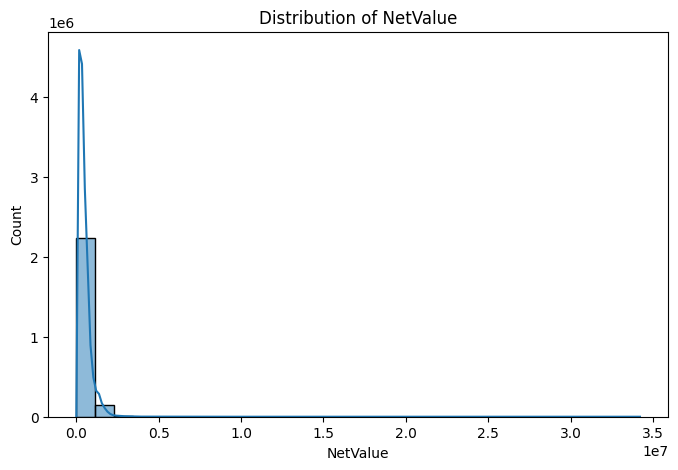

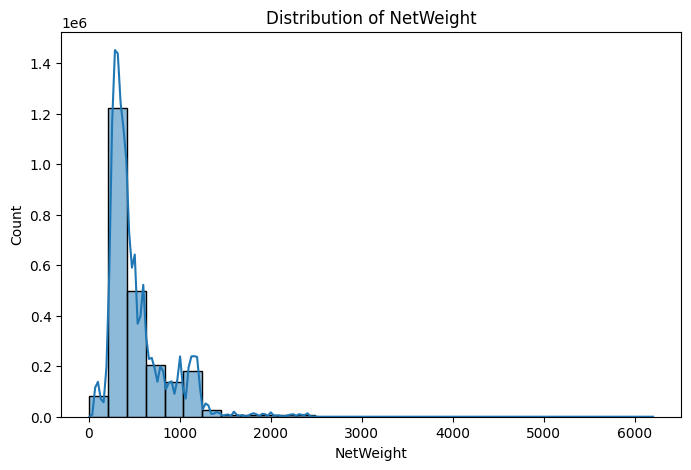

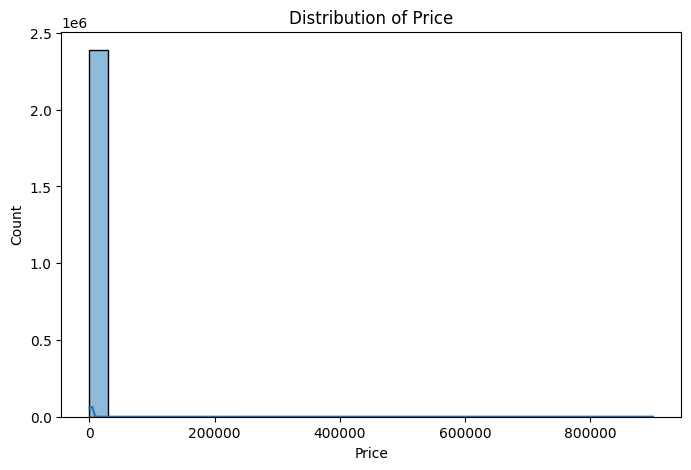

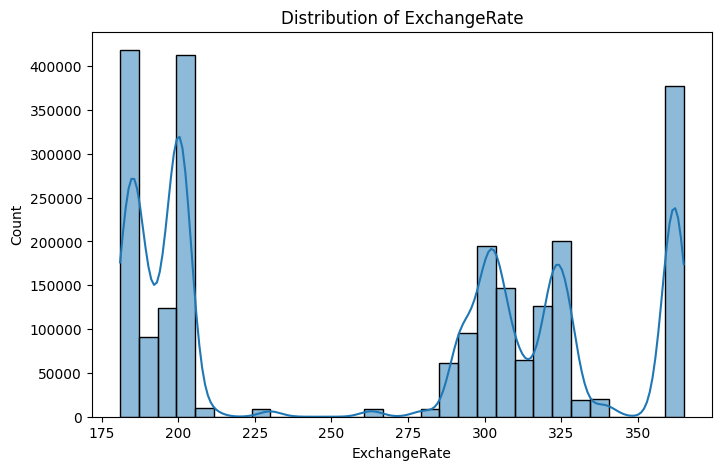

In [ ]:
# Numerical features
numerical_columns = ['NetValue', 'NetWeight','Price','ExchangeRate']
for col in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

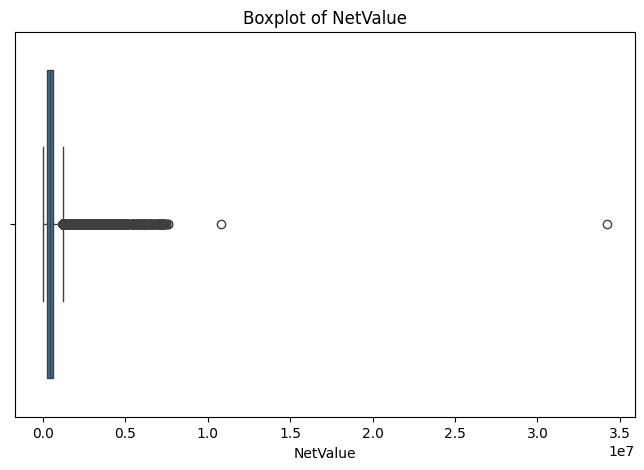

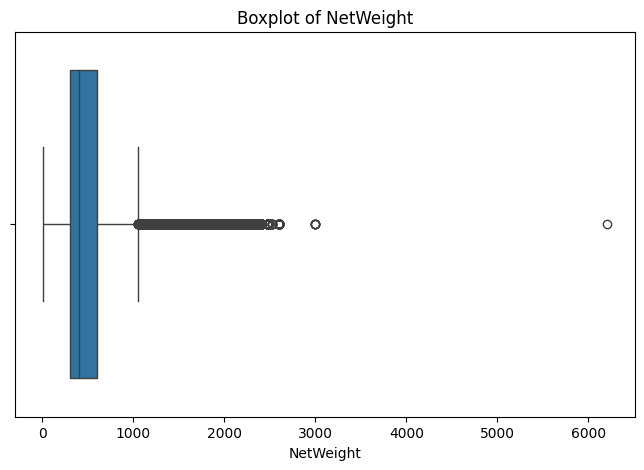

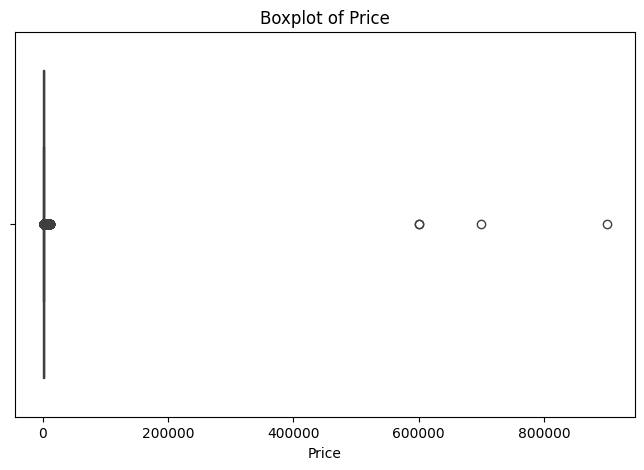

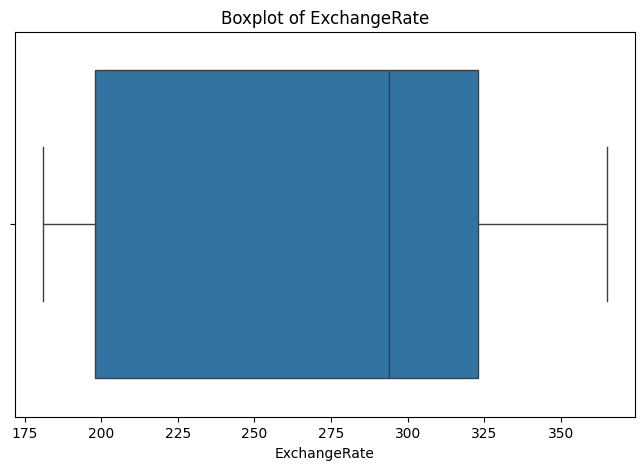

In [ ]:
# Check for outliers
for col in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

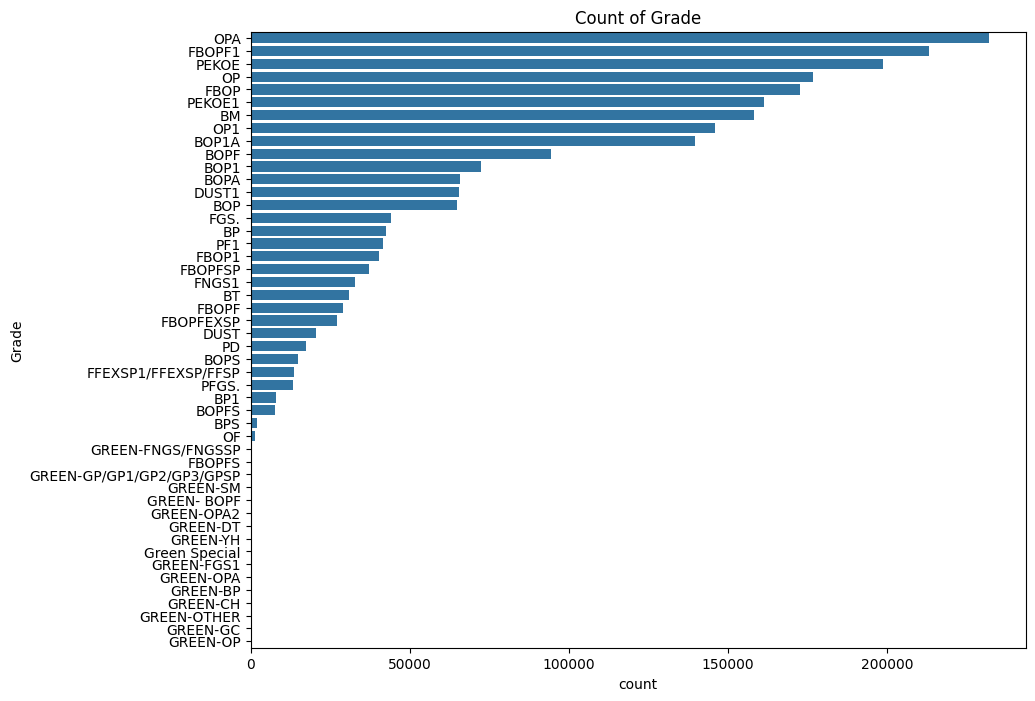

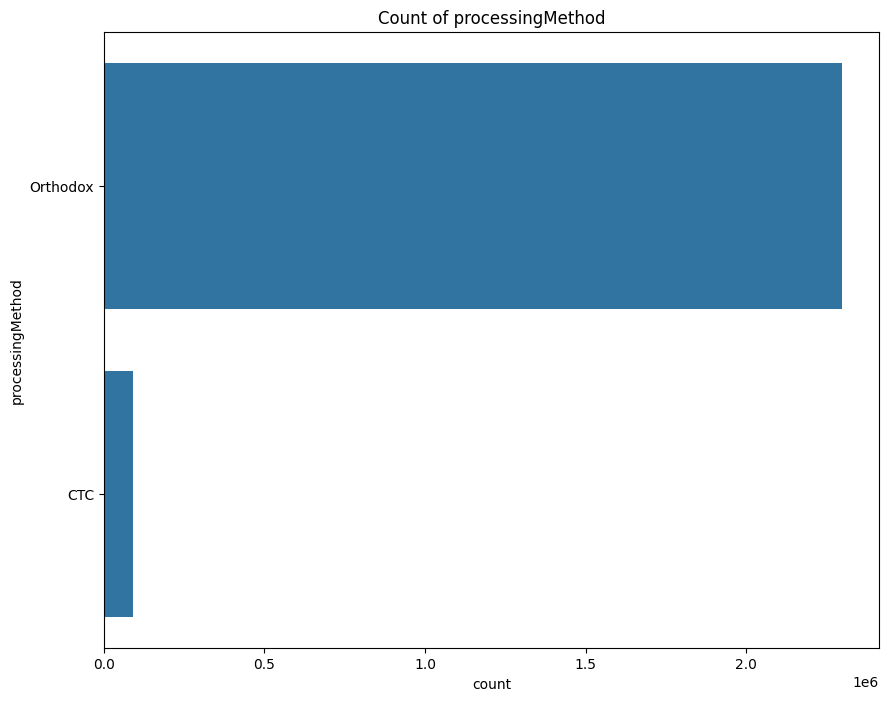

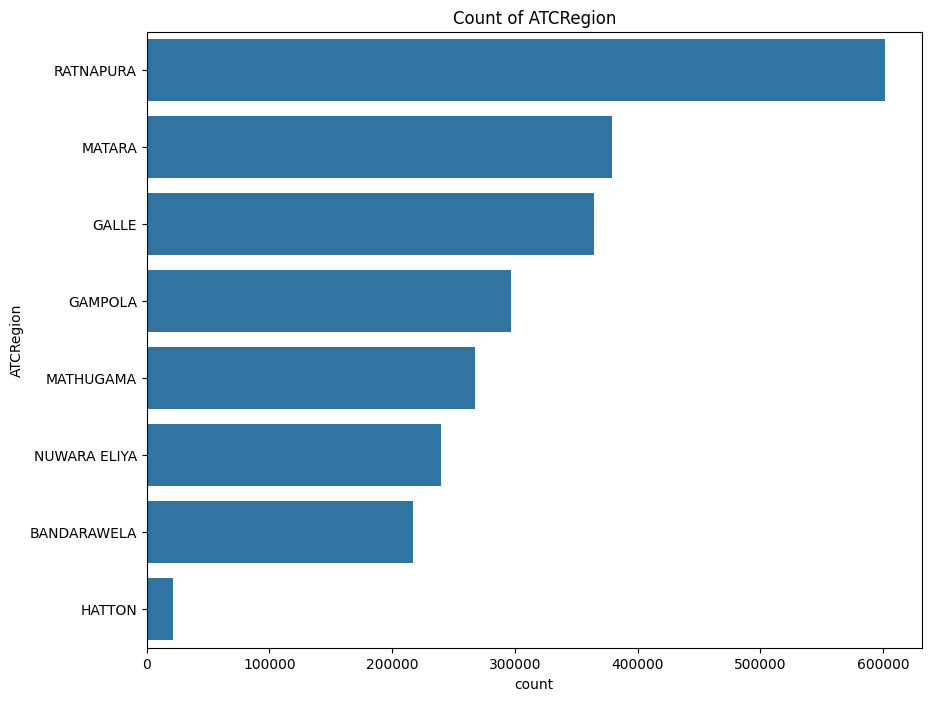

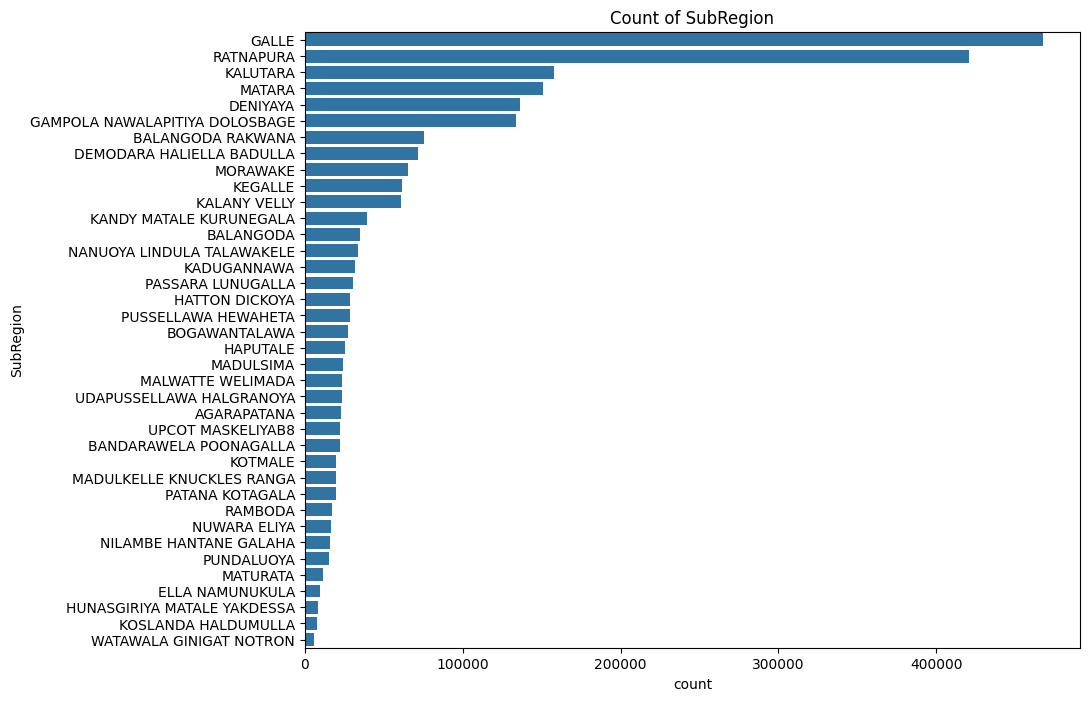

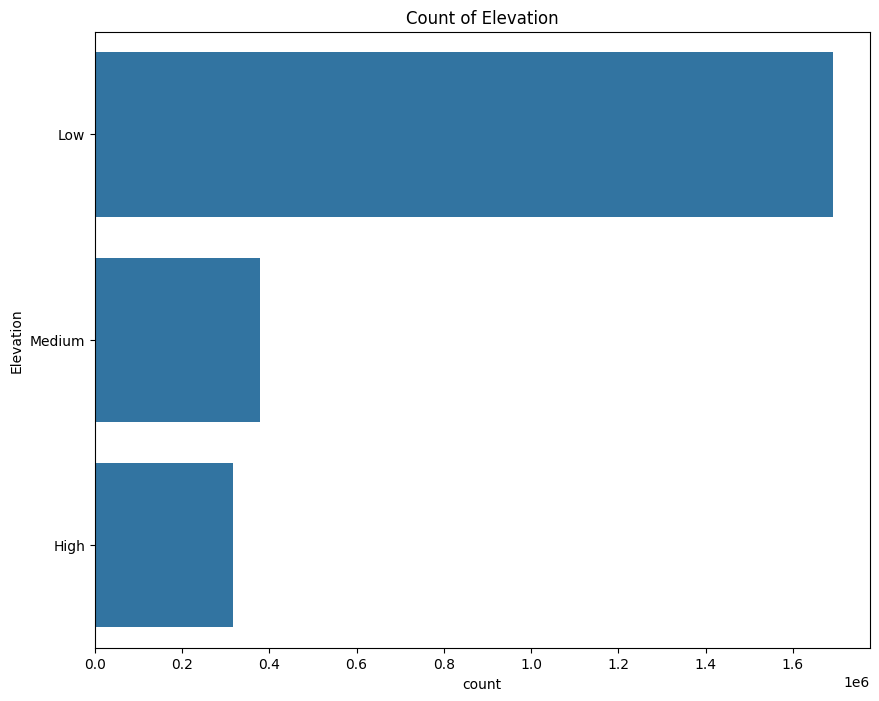

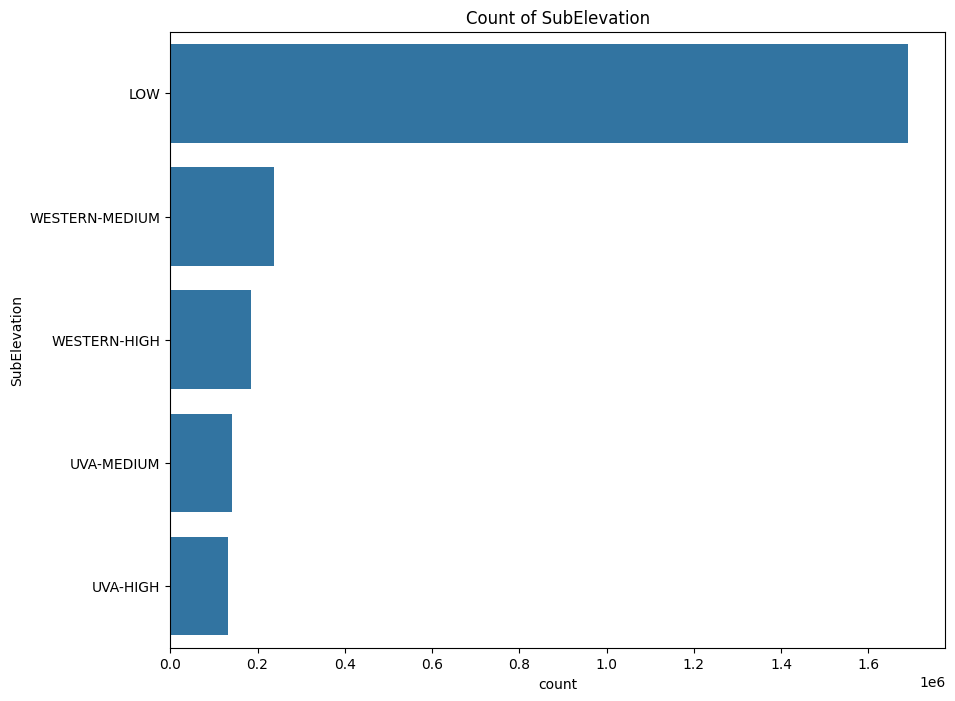

In [ ]:
# Categorical features

new_categorical_columns = ['Grade', 'processingMethod', 'ATCRegion','SubRegion', 'Elevation', 'SubElevation']
for col in new_categorical_columns:
    plt.figure(figsize=(10, 8))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.show()

**TREND ANALYSIS OF REVENUE (NetValue)**

In [ ]:
df_trend = df.copy()

In [ ]:
# Extract Month name
df_trend['Month_Name'] = df['SaleDate'].dt.month_name()

# Extract Year and Month
df_trend['YearMonth'] = df['SaleDate'].dt.to_period('M').astype(str)

In [ ]:
# Group data by Year and Month
grouped_data = df_trend.groupby(['SaleYear', 'Month_Name'])['NetValue'].sum().reset_index()

In [ ]:
pivot_data = grouped_data.pivot(index='Month_Name', columns='SaleYear', values='NetValue')

In [ ]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
pivot_data = pivot_data.reindex(month_order)

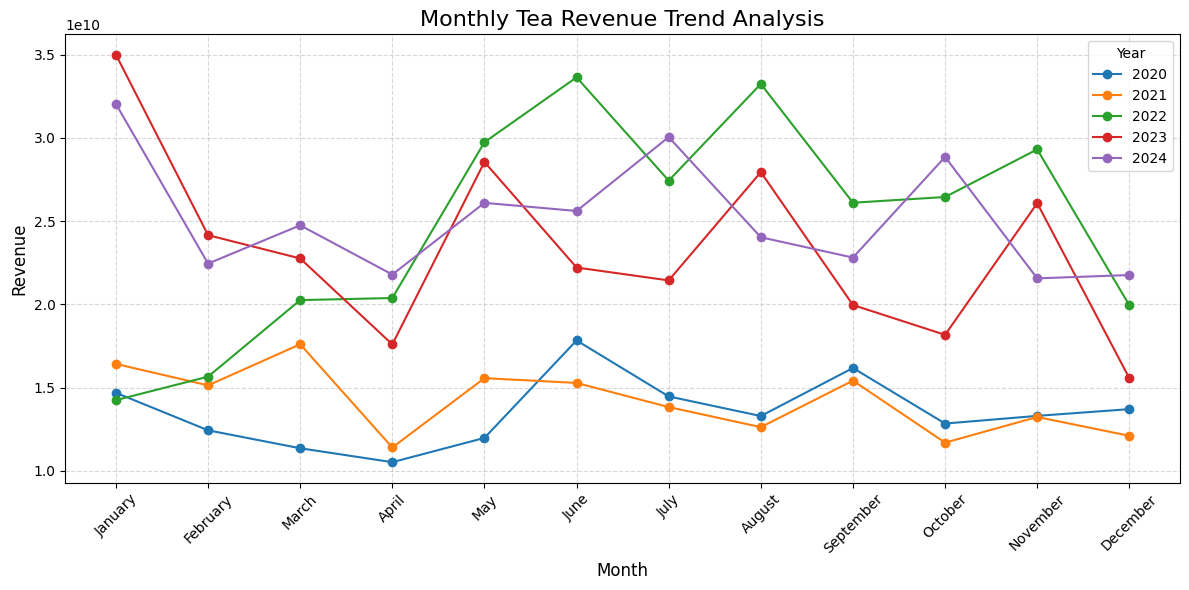

In [ ]:
# Plotting the line chart for revenue trend
plt.figure(figsize=(12, 6))
for year in pivot_data.columns:
    plt.plot(pivot_data.index, pivot_data[year], label=int(year), marker='o')

plt.title('Monthly Tea Revenue Trend Analysis', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Year', fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

**CLUSTERING**

In [ ]:
#Clustering Revenue based on the month and weight
df.dropna(subset=['SaleMonth', 'NetWeight', 'NetValue'], inplace=True)

# Monthly aggregation
monthly_data = df.groupby('SaleMonth').agg({
    'NetWeight': 'sum',
    'NetValue': 'sum'
}).reset_index()

In [ ]:
# import os
# Fix the number of logical cores
#os.environ["LOKY_MAX_CPU_COUNT"] = "4"

# Precaution for k-means
#os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
# Normalize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(monthly_data[['NetWeight', 'NetValue']])

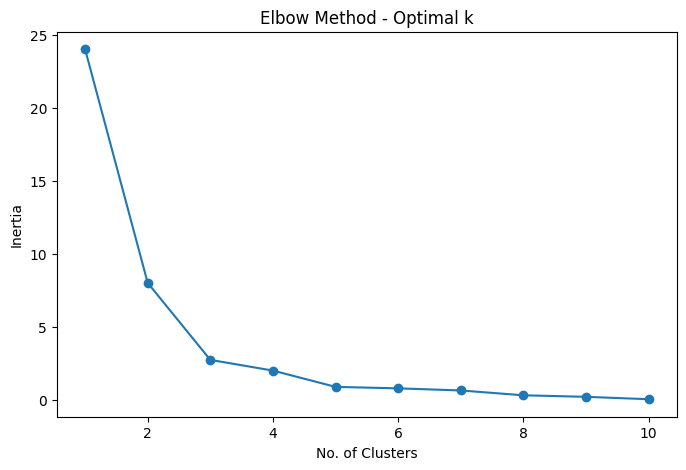

In [ ]:
# Elbow method - Optimal No. of clusters
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method - Optimal k')
plt.xlabel('No. of Clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
#K-Means clustering
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
monthly_data['Cluster'] = kmeans.fit_predict(scaled_features)

         SaleMonth     NetWeight      NetValue
Cluster                                       
0         6.666667  1.104845e+08  1.100864e+11
1         8.000000  8.215302e+07  8.237606e+10
2         2.000000  9.868352e+07  8.982201e+10
3         8.250000  1.025907e+08  9.966087e+10
4         3.500000  1.217530e+08  1.134710e+11


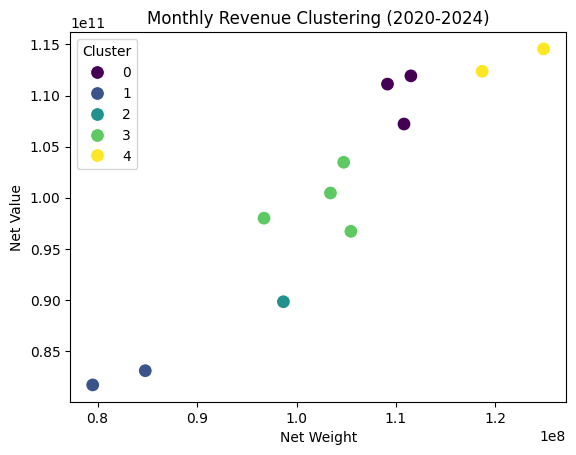

In [ ]:
# Cluster analysis
print(monthly_data.groupby('Cluster').mean())
sns.scatterplot(
    x=monthly_data['NetWeight'],
    y=monthly_data['NetValue'],
    hue=monthly_data['Cluster'],
    palette='viridis',
    s=100
)
plt.title('Monthly Revenue Clustering (2020-2024)')
plt.xlabel('Net Weight')
plt.ylabel('Net Value')
plt.show()

In [ ]:
# Months within each cluster
cluster_months = monthly_data.groupby('Cluster')['SaleMonth'].apply(list).reset_index()
print("Months in Each Cluster:")
print(cluster_months)

Months in Each Cluster:
   Cluster               SaleMonth
0        0         [5.0, 7.0, 8.0]
1        1             [4.0, 12.0]
2        2                   [2.0]
3        3  [3.0, 9.0, 10.0, 11.0]
4        4              [1.0, 6.0]


**High Revenue**: January, June  |
**Low Revenue**: April, December, February